In [2]:
# Retail Sales EDA — Superstore Dataset
Tools: Python · Pandas · Matplotlib · Seaborn  
Dataset: Sample Superstore (9,994 rows × 21 columns)  
Goal: Explore sales trends, top categories, regional performance, and the impact of discounts on profit.

SyntaxError: invalid character '·' (U+00B7) (3801386184.py, line 2)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("Sample - Superstore.csv", encoding="windows-1252")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df.shape

(9994, 21)

In [6]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [8]:
df.describe

<bound method NDFrame.describe of       Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
1          2  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
2          3  CA-2016-138688   6/12/2016   6/16/2016    Second Class   
3          4  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
4          5  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
...      ...             ...         ...         ...             ...   
9989    9990  CA-2014-110422   1/21/2014   1/23/2014    Second Class   
9990    9991  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9991    9992  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9992    9993  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9993    9994  CA-2017-119914    5/4/2017    5/9/2017    Second Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520    

In [9]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Order Month'] = df['Order Date'].dt.month
df['Order Year'] = df['Order Date'].dt.year
df['Month Name'] = df['Order Date'].dt.strftime('%b')

saggregating the columns from order date to order year , order month , order date

In [11]:
df[['Order Date','Order Month','Order Year']].head()

,Order Date,Order Month,Order Year
0,2016-11-08,11,2016
1,2016-11-08,11,2016
2,2016-06-12,6,2016
3,2015-10-11,10,2015
4,2015-10-11,10,2015


In [12]:
df['Profit Margin'] = df['Profit']/df['Sales'] * 100

In [13]:
df[['Profit','Sales','Profit Margin','Order Date','Order Month','Order Year']].head()

,Profit,Sales,Profit Margin,Order Date,Order Month,Order Year
0,41.9136,261.9600,16.00,2016-11-08,11,2016
1,219.5820,731.9400,30.00,2016-11-08,11,2016
2,6.8714,14.6200,47.00,2016-06-12,6,2016
3,-383.0310,957.5775,-40.00,2015-10-11,10,2015
4,2.5164,22.3680,11.25,2015-10-11,10,2015


C:\Users\kumaw\AppData\Local\Temp\ipykernel_11420\811746934.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df,x = 'Category' , y = 'Sales' , estimator=sum , ci = None , palette = 'muted')
C:\Users\kumaw\AppData\Local\Temp\ipykernel_11420\811746934.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x = 'Category' , y = 'Sales' , estimator=sum , ci = None , palette = 'muted')


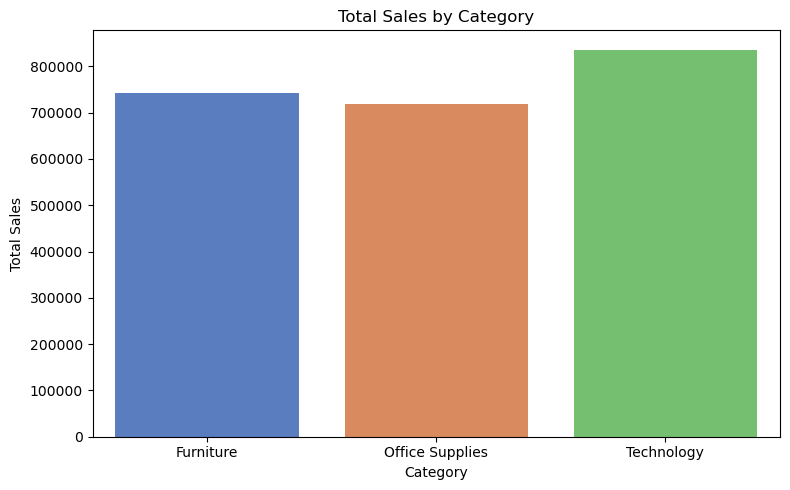

In [14]:
plt.figure(figsize =(8,5))
sns.barplot(data=df,x = 'Category' , y = 'Sales' , estimator=sum , ci = None , palette = 'muted')
plt.title('Total Sales by Category')
plt.ylabel('Total Sales')
plt.xlabel('Category')
plt.tight_layout()
plt.show()

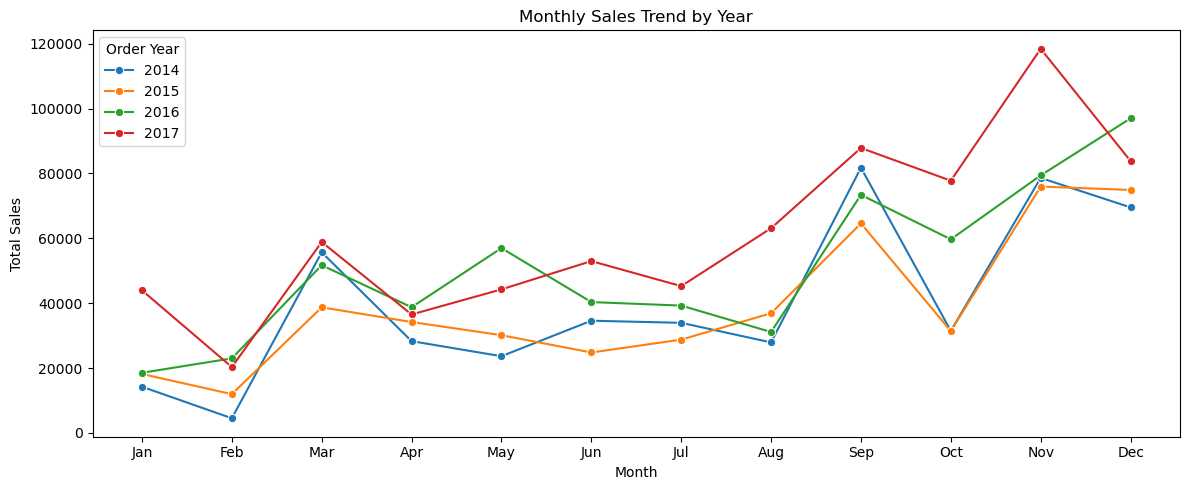

In [15]:
monthly_sales = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_sales, x='Order Month', y='Sales', hue='Order Year', marker='o', palette='tab10')
plt.title('Monthly Sales Trend by Year')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

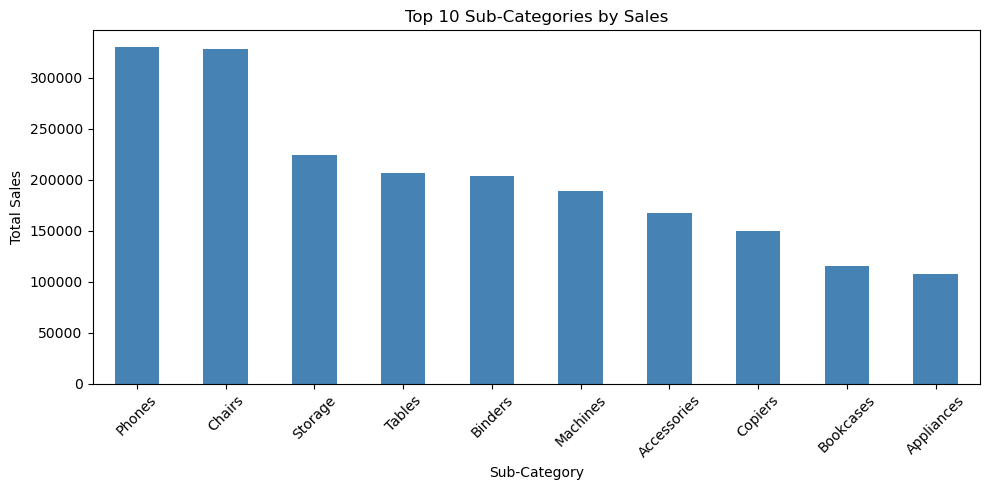

In [16]:
top_sub = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_sub.plot(kind='bar', color='steelblue')
plt.title('Top 10 Sub-Categories by Sales')
plt.ylabel('Total Sales')
plt.xlabel('Sub-Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\kumaw\AppData\Local\Temp\ipykernel_11420\3692178610.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Region', y='Profit', estimator=sum, ci=None, palette='coolwarm')
C:\Users\kumaw\AppData\Local\Temp\ipykernel_11420\3692178610.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Region', y='Profit', estimator=sum, ci=None, palette='coolwarm')


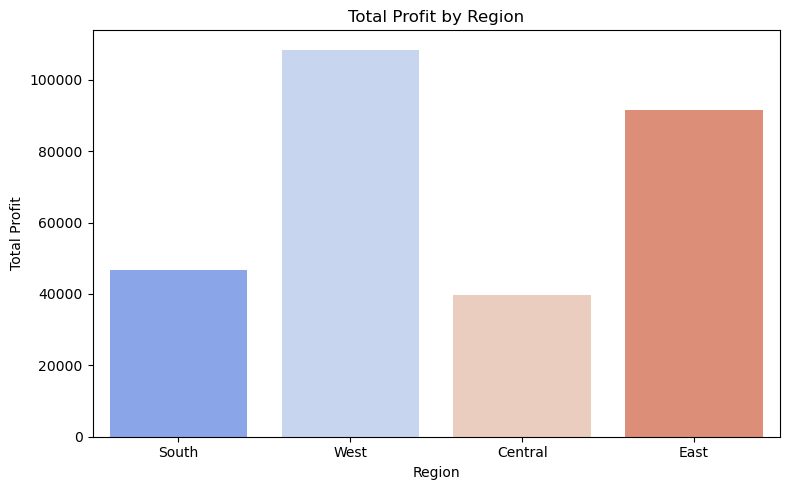

In [17]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Region', y='Profit', estimator=sum, ci=None, palette='coolwarm')
plt.title('Total Profit by Region')
plt.ylabel('Total Profit')
plt.xlabel('Region')
plt.tight_layout()
plt.show()

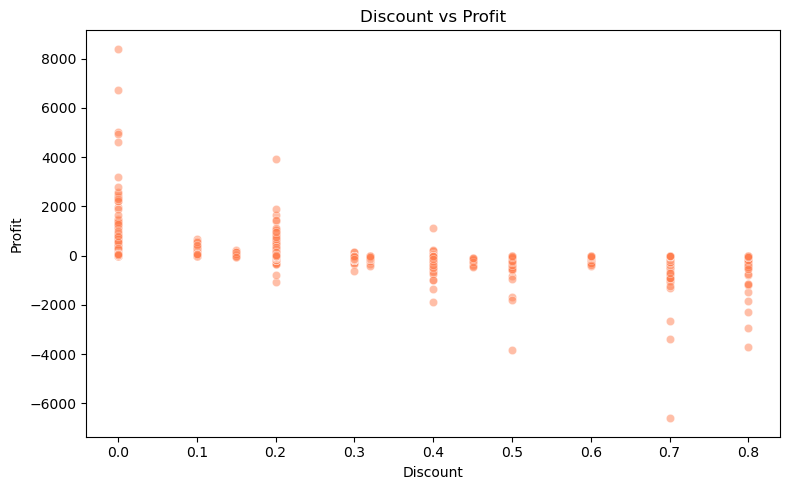

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.5, color='coral')
plt.title('Discount vs Profit')
plt.tight_layout()
plt.show()

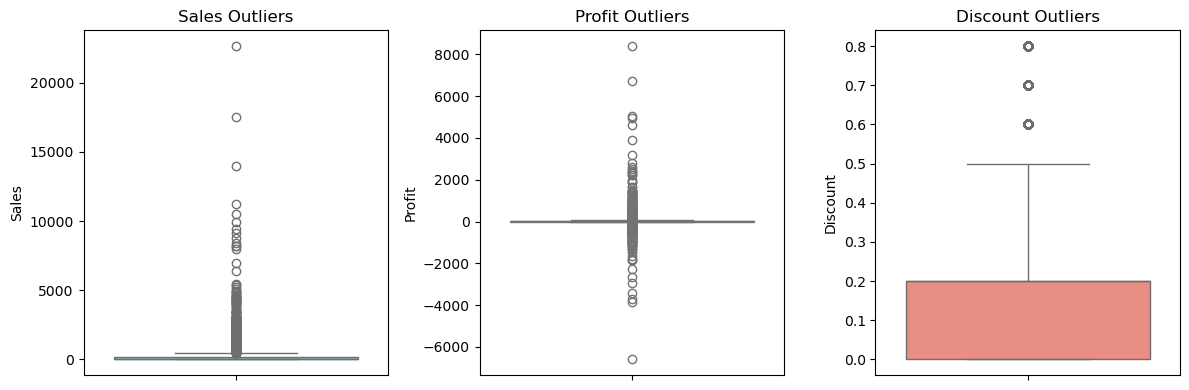

In [19]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.boxplot(y=df['Sales'], color='skyblue')
plt.title('Sales Outliers')

plt.subplot(1,3,2)
sns.boxplot(y=df['Profit'], color='lightgreen')
plt.title('Profit Outliers')

plt.subplot(1,3,3)
sns.boxplot(y=df['Discount'], color='salmon')
plt.title('Discount Outliers')

plt.tight_layout()
plt.show()

In [20]:
def count_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers | Lower bound: {lower:.2f} | Upper bound: {upper:.2f}")

count_outliers('Sales')
count_outliers('Profit')
count_outliers('Discount')

Sales: 1167 outliers | Lower bound: -271.71 | Upper bound: 498.93
Profit: 1881 outliers | Lower bound: -39.72 | Upper bound: 70.82
Discount: 856 outliers | Lower bound: -0.30 | Upper bound: 0.50


In [21]:
def remove_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[col] >= lower) & (data[col] <= upper)]

df_clean = remove_outliers(df, 'Sales')
df_clean = remove_outliers(df_clean, 'Profit')

print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")

Original shape: (9994, 25)
Cleaned shape: (7392, 25)
Rows removed: 2602


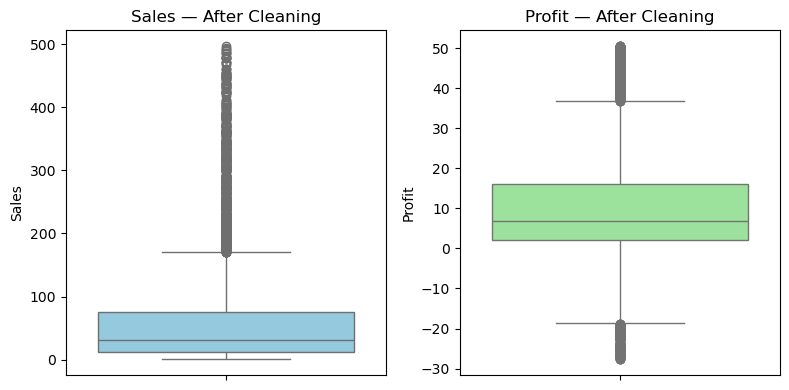

In [22]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
sns.boxplot(y=df_clean['Sales'], color='skyblue')
plt.title('Sales — After Cleaning')

plt.subplot(1,2,2)
sns.boxplot(y=df_clean['Profit'], color='lightgreen')
plt.title('Profit — After Cleaning')

plt.tight_layout()
plt.show()

In [ ]:
## Outlier Detection & Treatment
- Used the IQR (Interquartile Range) method to detect outliers in Sales and Profit.
- Outliers were found in both columns — extreme high-value orders skewing the data.
- Removed outliers to create `df_clean` for more reliable analysis.
- Discount had no significant outliers as values are bounded between 0 and 1.

In [25]:
print(" EDA Summary")
print("="*40)
print(f"Original dataset : {df.shape[0]} rows")
print(f"Cleaned dataset  : {df_clean.shape[0]} rows")
print(f"Outliers removed : {df.shape[0] - df_clean.shape[0]} rows")
print(f"Columns          : {df.shape[1]}")
print(f"Null values      : {df.isnull().sum().sum()}")
print(f"Years covered    : {df['Order Year'].min()} - {df['Order Year'].max()}")
print(f"Total Sales      : ${df['Sales'].sum():,.2f}")
print(f"Total Profit     : ${df['Profit'].sum():,.2f}")

📊 EDA Summary
Original dataset : 9994 rows
Cleaned dataset  : 7392 rows
Outliers removed : 2602 rows
Columns          : 25
Null values      : 0
Years covered    : 2014 - 2017
Total Sales      : $2,297,200.86
Total Profit     : $286,397.02
